In [6]:

import yfinance as yf
import pandas as pd

# Ticker symbol for Nifty Bank BeES (Requires .NS for Indian stocks on Yahoo Finance)
ticker = "BANKBEES.NS"

# Let's fetch data from 2020 to present
print("Fetching data...")
data = yf.download(ticker, start="2020-01-01", end="2026-05-01")

# Print the first 5 rows to see how the data looks
print(data.head())

/tmp/ipykernel_9731/1261561773.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2026-05-01")
[*********************100%***********************]  1 of 1 completed

Fetching data...
Price            Close        High         Low        Open      Volume
Ticker     BANKBEES.NS BANKBEES.NS BANKBEES.NS BANKBEES.NS BANKBEES.NS
Date                                                                  
2020-01-01  328.309998  330.100006  327.399994  329.200012       18548
2020-01-02  331.929993  332.950012  328.510010  332.950012       31931
2020-01-03  326.540009  330.100006  325.890015  329.149994     1082930
2020-01-06  319.179993  325.179993  318.000000  325.049988      237648
2020-01-07  320.170013  324.799988  318.079987  321.600006     1099389


In [7]:

# In newer versions of yfinance, columns are MultiIndex. Let's flatten them.
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

# 1. Create Moving Averages
data['MA_10'] = data['Close'].rolling(window=10).mean()
data['MA_50'] = data['Close'].rolling(window=50).mean()

# 2. Daily Return - Percentage change compared to yesterday
data['Daily_Return'] = data['Close'].pct_change()

# 3. Create Target Variable (Tomorrow's price)
# We want to predict tomorrow's price using today's data, so we shift the Close price by -1
data['Target'] = data['Close'].shift(-1)

# Due to rolling (50 days) and shifting, some initial and final rows become NaN.
# Let's drop these Null values.
df = data.dropna().copy()

print("Feature Engineering completed!")
print("Total rows:", len(df))
print(df[['Close', 'MA_10', 'MA_50', 'Daily_Return', 'Target']].head())

Feature Engineering completed!
Total rows: 1516
Price            Close       MA_10     MA_50  Daily_Return      Target
Date                                                                  
2020-03-12  244.889999  285.603999  311.9228     -0.095078  257.760010
2020-03-13  257.760010  280.637999  310.5118      0.052554  239.970001
2020-03-16  239.970001  274.962999  308.6726     -0.069018  226.350006
2020-03-17  226.350006  268.152998  306.6688     -0.056757  210.119995
2020-03-18  210.119995  259.337999  304.4876     -0.071703  203.570007


In [8]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# 1. Separate X (Features/Inputs) and y (Target/Output)
features = ['Close', 'Open', 'High', 'Low', 'Volume', 'MA_10', 'MA_50', 'Daily_Return']
X = df[features]
y = df['Target']

# 2. Split into Train and Test Data (80% for training, 20% for testing)
# Since this is Time Series data, keeping shuffle=False is extremely important!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Rows available for training: {X_train.shape[0]}")
print(f"Rows available for testing: {X_test.shape[0]}")

# 3. Select and train the model (Random Forest)
print("\nTraining the model... please wait.")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model training completed!")

# 4. Make predictions on the test data
predictions = model.predict(X_test)

# 5. Create a DataFrame to compare Actual vs Predicted prices
results = pd.DataFrame({
    'Actual_Price': y_test,
    'Predicted_Price': predictions
}, index=X_test.index)

print("\nFirst 5 prediction results:")
print(results.head())

Rows available for training: 1212
Rows available for testing: 304

Training the model... please wait.
Model training completed!

First 5 prediction results:
            Actual_Price  Predicted_Price
Date                                     
2025-02-01    505.839996       508.333597
2025-02-03    513.880005       504.032301
2025-02-04    516.090027       509.255999
2025-02-05    516.989990       516.292490
2025-02-06    514.530029       516.645185


--- Model Evaluation (Regression Metrics) ---
Mean Absolute Error (MAE): ₹34.09 (On average, the model is off by this amount)
Root Mean Squared Error (RMSE): ₹41.90


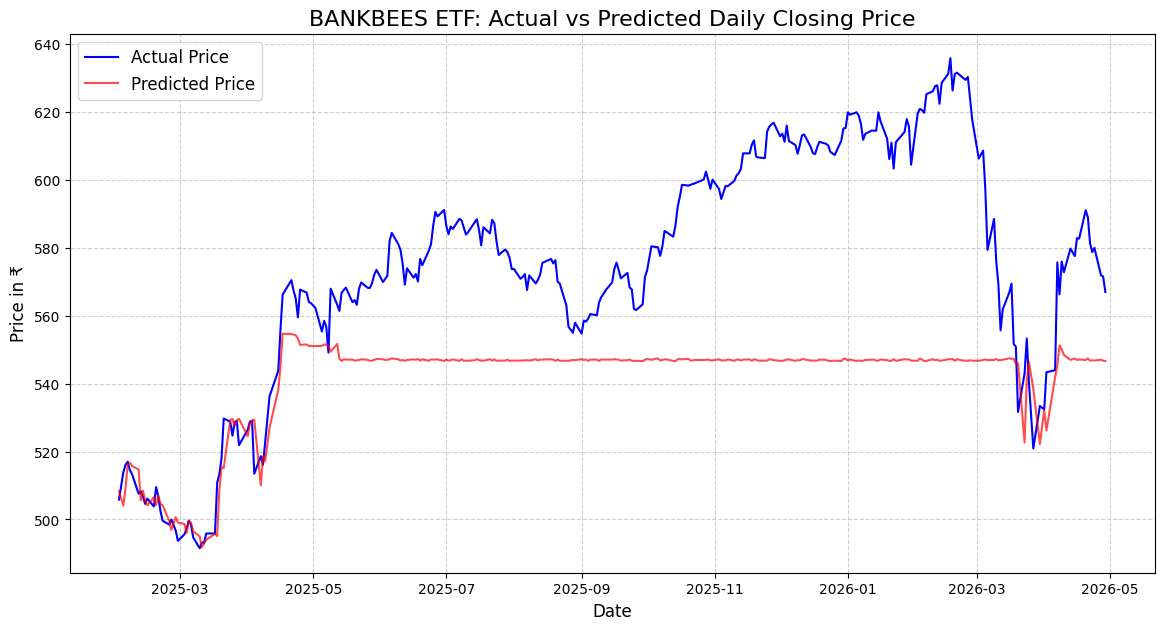

In [9]:

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Calculate Error Metrics
mae = mean_absolute_error(results['Actual_Price'], results['Predicted_Price'])
mse = mean_squared_error(results['Actual_Price'], results['Predicted_Price'])
rmse = np.sqrt(mse)

print("--- Model Evaluation (Regression Metrics) ---")
print(f"Mean Absolute Error (MAE): ₹{mae:.2f} (On average, the model is off by this amount)")
print(f"Root Mean Squared Error (RMSE): ₹{rmse:.2f}")

# 2. Create a plot of the results
plt.figure(figsize=(14, 7))

# Blue line for actual price
plt.plot(results.index, results['Actual_Price'], label='Actual Price', color='blue')

# Red line for predicted price
plt.plot(results.index, results['Predicted_Price'], label='Predicted Price', color='red', alpha=0.7)

# Add title and labels to the graph
plt.title('BANKBEES ETF: Actual vs Predicted Daily Closing Price', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price in ₹', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Display the graph
plt.show()